In [1100]:
"""
02_preprocess.ipynb
===================
Applies preprocessing to well-level morphological profiles.
Follows Step 1 of the analysis pipeline.

Inputs:
    - data/processed/all_profiles.csv

Outputs:
    - TBD
"""

'\n02_preprocess.ipynb\n===================\nApplies preprocessing to well-level morphological profiles.\nFollows Step 1 of the analysis pipeline.\n\nInputs:\n    - data/processed/all_profiles.csv\n\nOutputs:\n    - TBD\n'

In [1101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import rankdata, skew, yeojohnson, kstest, norm, yeojohnson_normmax
from pathlib import Path

DATA_DIR = Path("../data/processed")
df = pd.read_csv(DATA_DIR / "all_profiles.csv")

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Identify meta data andfeature columns (everything that is not metadata)
df = df.rename(columns={"Row": "row", "Column": "column", "Number of Analyzed Fields": "num_wells"})
meta_cols = ["plate_name", "session", "row", "column", "compound", "dose_uM", "cell_type", "condition", "num_wells"]
original_feature_cols = [c for c in df.columns if c not in meta_cols]

In [1102]:
def remove_low_variance_features(df, feature_cols, non_zero_rate_thresh=0.1):
    """
    Removes constant (zero variance) and low prevalence (< 10% of values non-zero) features as a first cleaning step.n.
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        non_zero_rate_thresh: minimum fraction of non-zero values required to retain a feature (default 0.1)
    
    Returns:
        df_clean: dataframe with low-variance features removed
        retained: list of retained feature column names
    """
    df_clean = df.copy()
    
    # Compute per-feature metrics
    std = df_clean[feature_cols].std()
    non_zero_rate = (df_clean[feature_cols] != 0).mean()
    
    # Masks
    mask_constant = std <= 1e-6
    mask_low_prevalence = ~mask_constant & (non_zero_rate <= non_zero_rate_thresh)
    mask_retain = ~(mask_constant | mask_low_prevalence)
    
    # Lists of features
    removed_constant = std[mask_constant].index.tolist()
    removed_low_prevalence = non_zero_rate[mask_low_prevalence].index.tolist()
    retained = std[mask_retain].index.tolist()
    
    # Print summary
    print(f"Feature cleaning summary:")
    print(f"  Total features: {len(feature_cols)}")
    print(f"  Removed features: {len(removed_constant) + len(removed_low_prevalence)}")
    print(f"    Constant features (std <= {1e-6}): {len(removed_constant)}")
    print(f"    Low prevalence features (non-zero rate <= {non_zero_rate_thresh * 100:.1f}%): {len(removed_low_prevalence)}")
    print(f"  Retained features: {len(retained)}")
    
    if removed_constant:
        print(f"\nRemoved {len(removed_constant)} constant features:")
        print("\n".join(f"  {f}" for f in removed_constant))
    if removed_low_prevalence:
        print(f"\nRemoved {len(removed_low_prevalence)} low-prevalence features:")
        print("\n".join(f"  {f}" for f in removed_low_prevalence))
    
    # Drop removed features
    df_clean = df_clean.drop(columns=removed_constant + removed_low_prevalence)

    return df_clean, retained

In [1103]:
# Helper functions for 1b. Plate Effects

def plot_plate_heatmap(df, feature, plate_indices=(0, 1)):
    """
    Visualizes a single feature as spatial heatmaps for two selected plates side by side.
    Layout mirrors the physical plate, so spatial artifacts should be visually apparent.
    
    Args:
        df: profiles dataframe
        feature: feature column name to visualize
        plate_indices: tuple of two plate indices selecting plates by sorted order
    """
    plates = sorted(df['plate_name'].unique())
    selected_plates = [plates[i] for i in plate_indices]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), squeeze=False)
    
    for i, plate in enumerate(selected_plates):
        plate_df = df[df['plate_name'] == plate].copy()
        condition = plate_df.pivot(index='row', columns='column', values='condition').sort_index()
        condition_mapping = ", ".join(
            f"{cond[0].upper()} = {cond}"
            for cond in pd.unique(condition.values.ravel())  # flatten 2D array
            if pd.notna(cond)  # ignore NaN
        )
        grid = plate_df.pivot(index='row', columns='column', values=feature).sort_index()
        
        sns.heatmap(
            grid,
            ax=axes[0, i],
            cmap='Blues',
            center=grid.values[~np.isnan(grid.values)].mean(),
            annot=[[str(val)[0].upper() for val in row] for row in condition.values],
            fmt='',
            annot_kws={"size": 11},
            linewidths=0.5,
            linecolor='grey',
            cbar_kws={'label': feature.split(' - ')[1] if ' - ' in feature else feature} if i == 1 else None
        )
        
        axes[0, i].set_title(f"Plate {plate}\n\n", fontsize=12, fontweight='bold')
        axes[0, i].text(
            0.5, 1.01,
            f"{feature}\n{condition_mapping}",
            ha='center', va='bottom', fontsize=10, transform=axes[0, i].transAxes
        )
        axes[0, i].set_xlabel("column")
        axes[0, i].set_ylabel("row")
    
    plt.tight_layout()
    plt.show()

def correct_plate_layout(df):
    """
    Corrects spatial artifacts within each plate (Step 1b).
    Suggested approach: two-way median polish (B-score).
    Note: median polish may not be appropriate if plate layout is structured
    (e.g., dose series along rows/columns) — consider 2D polynomial regression instead.
    NOTE: Did not implement since plate effects were not visually apparent, but can re-check once cell counts are added.
    
    Args:
        df: profiles dataframe
    
    Returns:
        df with layout-corrected feature values
    """
    pass

In [1104]:
# Helper functions for 1c. Batch Effects

def detect_batch_effects(df, feature_cols, reference="healthy", similarity="pearson"):
    """
    Detects batch effects across plates by inspecting pairwise correlations (Step 1c).
    Plots correlation heatmap of healthy wells sorted by plate — batch effects appear as high-correlation blocks grouped by plate.
    Within-plate and across-plate correlations should be in the same range.
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        sort_by: column to sort wells by (default: plate_name)
        similarity: method to compute similarity ('pearson' or 'cosine', default 'pearson'). Cosine better when data is normalized.
    """
    # Filter to reference wells only (healthy - WT/WT and NEG CTRL, or disease - WT/MT and NEG CTRL)
    reference_df = df[df["condition"] == reference].copy()
    # Sort by plate so batch blocks are visible
    reference_df = reference_df.sort_values("plate_name").reset_index(drop=True)
    
    # Compute pairwise similarity matrix (Pearson correlation or cosine similarity) across wells
    if similarity == 'cosine':
        from sklearn.metrics.pairwise import cosine_similarity
        corr_matrix = pd.DataFrame(
            cosine_similarity(reference_df[feature_cols]),
            index=reference_df.index,
            columns=reference_df.index
        )
    else:
        corr_matrix = reference_df[feature_cols].T.corr()
    
    # Build tick labels and boundary lines for plate groups
    plate_labels = reference_df["plate_name"].values
    groups = reference_df.groupby("plate_name", sort=False).indices
    tick_positions = [np.mean(idx) + 0.5 for idx in groups.values()]
    tick_labels = list(groups.keys())
    boundaries = [idx[0] for idx in groups.values()][1:] # Starts of each plate (skip the first)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        ax=ax,
        cmap="flare",
        center=corr_matrix.values.mean(),
        vmin=corr_matrix.values.min(),
        vmax=1,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"label": "Pearson correlation"}
    )
    
    # Draw plate boundary lines
    for b in boundaries:
        ax.axhline(b, color="black", linewidth=1)
        ax.axvline(b, color="black", linewidth=1)
    
    # Add plate labels on x and y axis
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)
    
    # Get within-plate vs across-plate correlation summary
    within = []
    across = []
    for i in range(len(plate_labels)):
        for j in range(i + 1, len(plate_labels)):
            val = corr_matrix.iloc[i, j]
            if plate_labels[i] == plate_labels[j]:
                within.append(val)
            else:
                across.append(val)

    ax.set_title(f"Pairwise Correlation of {reference.capitalize()} Wells by Plate\n\n", fontsize=14, fontweight='bold')

    # Add within-plate vs across-plate correlation as image subtitle
    ax.text(
        0.5, 1.01,
        f"\nWithin-plate correlation: {np.mean(within):.3f} ± {np.std(within):.3f} | "
        f"Across-plate correlation: {np.mean(across):.3f} ± {np.std(across):.3f}\n"
        "If these are similar, no strong batch effect detected.",
        ha='center', va='bottom', fontsize=11, transform=ax.transAxes
    )
    plt.tight_layout()
    plt.show()

    print(f"Within-plate correlation: {np.mean(within):.3f} ± {np.std(within):.3f}")
    print(f"Across-plate correlation: {np.mean(across):.3f} ± {np.std(across):.3f}")

In [1105]:
# Helper functions for 1d. Normalization and Transformation

# NOTE: batch correction is embedded in the normalization function if a level is specified (ex. plate-level normalization should correct batch effects)
# However, if want to use different batch correction method than normalization (e.g. CCA), can implement separately and run before normalization
def normalize_features(df, feature_cols, level=None):
    """
    Robust z-scoring against healthy reference wells (Step 1d).
    z = (value - median_healthy) / MAD_healthy
    
    Per the Nature article: normalize within plates when batch effects exist,
    globally when batch effects are absent (plates are already comparable).
    
    Args:
        df: profiles dataframe (ideally already transformed)
        feature_cols: list of feature column names
        level: level at which to normalize (None for global, 'batch' for batch-level, 'session' for session-level, 'plate_name' for plate-level)
    
    Returns:
        df with normalized feature values
    """
    df_normalized = df.copy()

    if level is not None:
        print(f"Normalizing features per {level} (batch effects present) so healthy wells have median ~0. Verifying symmetry via mean...")
        print(f"{'Batch':<30} {'Healthy Mean':<15} {'Wells':<10}")
        print("-" * 55)
        means = []

        for group in df[level].unique():
            # Get reference (healthy) well values for batch
            group_mask = df[level] == group
            ref_mask = group_mask & (df['condition'] == 'healthy')
            ref_vals = df.loc[ref_mask, feature_cols]

            median = ref_vals.median()
            mad = (ref_vals - median).abs().median() * 1.4826
            mad[mad < 1e-4] = 1.0

            df_normalized.loc[group_mask, feature_cols] = (df.loc[group_mask, feature_cols] - median) / mad
            group_mean = df_normalized.loc[ref_mask, feature_cols].mean().mean()
            means.append(group_mean)
            print(f"{group:<30} {group_mean:<15.6f} {int(ref_mask.sum()):<10}")
            
        print("-" * 55)
        print(f"Healthy mean across all {level}s: {np.mean(means):.6f}")
    
    else:
        print("Normalizing globally (no batch effects):")
        ref_mask = df['condition'] == 'healthy'
        ref_vals = df.loc[ref_mask, feature_cols]

        median = ref_vals.median()
        mad = (ref_vals - median).abs().median() * 1.4826
        mad[mad < 1e-4] = 1.0

        df_normalized[feature_cols] = (df[feature_cols] - median) / mad
        global_mean = df_normalized.loc[ref_mask, feature_cols].mean().mean()
        print(f"  Healthy reference wells: {ref_mask.sum()} across {df['plate_name'].nunique()} plates")
        print(f"  Healthy mean after normalization: {global_mean:.6f}")

    return df_normalized

def transform_features(df, feature_cols, skew_threshold=1.0, method='yeo-johnson'):
    """
    Flags and transforms skewed features before normalization (Step 1d).
    Compute skewness per feature; apply transformation (e.g., Yeo-Johnson) to features exceeding the skew threshold.
    Skip transformation if variance is unstable or if it does not improve skewness.
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        skew_threshold: absolute skewness threshold (default 1.0) beyond which to apply transformation
        method: transformation method to apply ('yeo-johnson' or 'asinh')
    
    Returns:
        df with transformed feature values
    """
    df_transformed = df.copy()

    # 1. Determine skewness
    feature_skewness = df[feature_cols].skew()
    transformed_features = feature_skewness[abs(feature_skewness) > skew_threshold].index.tolist()
    print(f"{len(transformed_features)} of {len(feature_cols)} features exceed |skew| > {skew_threshold}.")
    
    # Save skewed features before transformation for inspection
    skew_inspection_file = OUTPUT_DIR / "01_skewed_features_before.csv"
    df[transformed_features].to_csv(skew_inspection_file, index=False)
    print(f"  Saved skewed features to: {skew_inspection_file} for inspection.\n")
    
    skipped_features = []
    
    # 2. Apply transformation and check if skewness improved; if not, keep original values
    for col in transformed_features:
        orig_data = df[col]
        orig_skew = abs(feature_skewness[col])
        
        # NOTE: could consider estimating lambda for Yeo-Johnson based on healthy reference wells only
        # Applying to all wells here for consistency and because of skew improvement downstream, but can re-check
        if method == 'yeo-johnson':
            transformed, _ = yeojohnson(orig_data)
        # NOTE: arcsinh is a common alternative that can also handle zero and negative values; scale by IQR to stabilize variance
        elif method == 'asinh':
            q10, q90 = np.nanpercentile(orig_data, [10, 90])
            scale = (q90 - q10) / 2.0 if (q90 - q10) > 0 else 1.0
            transformed = np.arcsinh(orig_data / scale)
        else:
            raise ValueError(f"Unsupported transformation method: {method}. Pick 'yeo-johnson' or 'asinh'.")
        
        # Check if skewness improved and variance is not too low; if not, revert to original
        # May be the case when feature is very sparse or has extreme outliers; in this case better to keep original than unstable transformed version
        new_skew = abs(pd.Series(transformed).skew())
        if not np.isfinite(transformed).all() or np.nanstd(transformed) <= 1e-10:
            skipped_features.append((col, orig_skew, new_skew, "variance unstable"))
            df_transformed[col] = orig_data
        elif new_skew >= orig_skew:
            skipped_features.append((col, orig_skew, new_skew, "skew did not improve"))
            df_transformed[col] = orig_data
        else:
            df_transformed[col] = transformed

    n_transformed = len(transformed_features) - len(skipped_features)
    after_skew = df_transformed[transformed_features].skew()
    
    print(f"{method.capitalize()} transformed {n_transformed} of {len(transformed_features)} flagged features:")
    print(f"  Mean |skewness| before: {feature_skewness[transformed_features].abs().mean():.3f}")
    print(f"  Mean |skewness| after:  {after_skew.abs().mean():.3f}")
    
    if skipped_features:
        print(f"\n  Skipped {len(skipped_features)} features where transformation unstable/did not improve skewness:")
        for col, orig, new, reason in skipped_features:
            print(f"    {col[:80]}: skew {orig:.3f} -> {new:.3f} ({reason})")
    
    return df_transformed

In [1106]:
print("="*60)
print("1. REMOVE ZERO-VARIANCE AND LOW-PREVALENCE FEATURES")
print("="*60)
print()

df_clean, feature_cols = remove_low_variance_features(df, original_feature_cols, non_zero_rate_thresh=0.1)

1. REMOVE ZERO-VARIANCE AND LOW-PREVALENCE FEATURES

Feature cleaning summary:
  Total features: 2136
  Removed features: 12
    Constant features (std <= 1e-06): 8
    Low prevalence features (non-zero rate <= 10.0%): 4
  Retained features: 2124

Removed 8 constant features:
  Plane
  Timepoint
  Height [µm]
  Time [s]
  Nuclei - CellPainting Ring Region PhenoVue Hoechst 33342 Profile 1/2 SER-Hole - Median per Well
  Nuclei - CellPainting Ring Region PhenoVue Hoechst 33342 Profile 2/2 SER-Hole - Median per Well
  Nuclei - CellPainting Ring Region PhenoVue Hoechst 33342 SER Hole 2 px - Median per Well
  Nuclei - CellPainting Ring Region Sapphire Profile 2/2 SER-Hole - Median per Well

Removed 4 low-prevalence features:
  Nuclei - CellPainting Ring Region PhenoVue Hoechst 33342 Profile 2/2 SER-Dark - Median per Well
  Nuclei - CellPainting Ring Region PhenoVue Hoechst 33342 Profile 2/2 SER-Valley - Median per Well
  Nuclei - CellPainting Ring Region Sapphire Profile 1/2 SER-Hole - Media

2. EXAMINE PLATE LAYOUT EFFECTS WITH SPATIAL HEATMAPS

NOTE: Only plate indices 12 and 13 have data for all wells.
(other plates have MT/MT conditon which was removed, so harder to see plate layout effects)


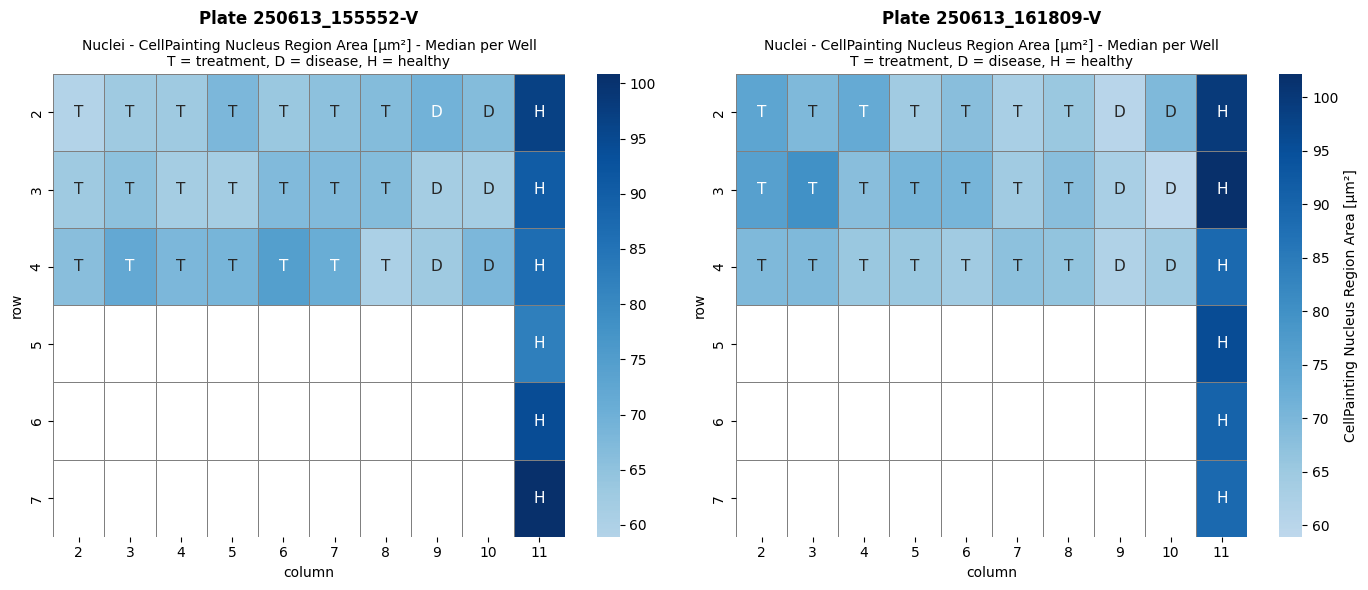


No strong plate effects apparent; can revise after cell-counts added.
Skipping correction.



In [1107]:
print("="*60)
print("2. EXAMINE PLATE LAYOUT EFFECTS WITH SPATIAL HEATMAPS")
print("="*60)
print()

print("NOTE: Only plate indices 12 and 13 have data for all wells.\n(other plates have MT/MT conditon which was removed, so harder to see plate layout effects)")

plate_effect_feature = 'Nuclei - CellPainting Nucleus Region Area [µm²] - Median per Well'
plot_plate_heatmap(df_clean, plate_effect_feature, plate_indices=(1, 2))

print("\nNo strong plate effects apparent; can revise after cell-counts added.\nSkipping correction.\n")

3. EXAMINE BATCH EFFECTS WITH CORRELATION HEATMAPS



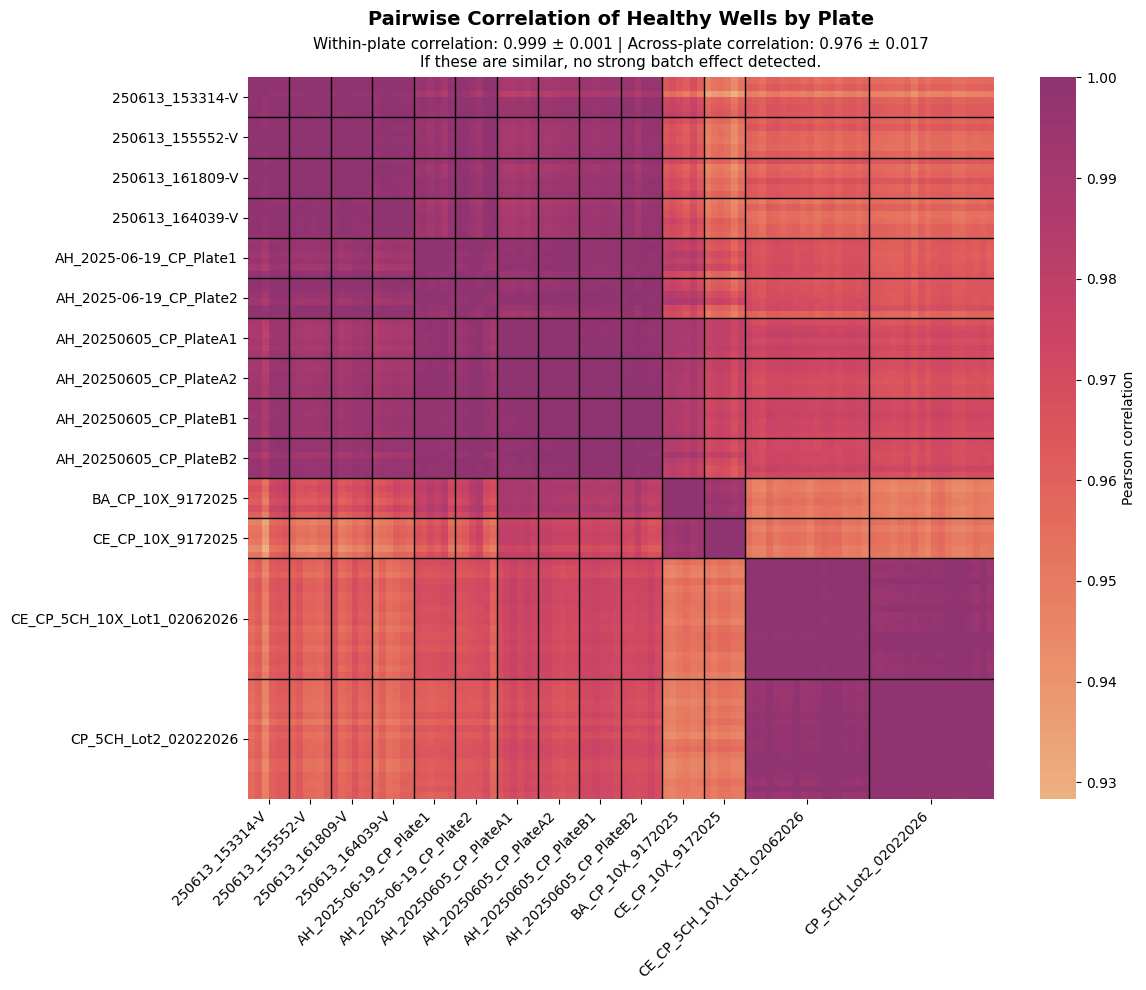

Within-plate correlation: 0.999 ± 0.001
Across-plate correlation: 0.976 ± 0.017


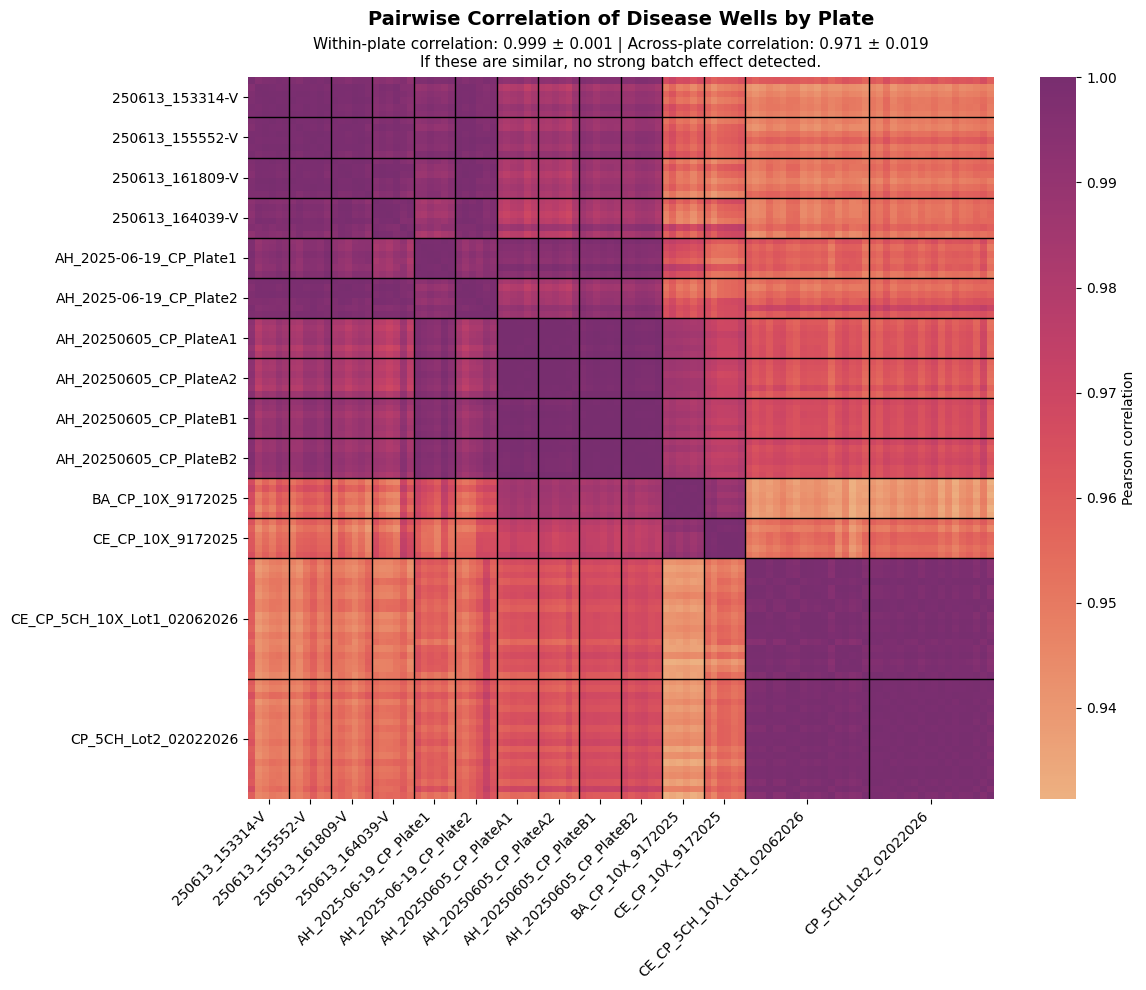

Within-plate correlation: 0.999 ± 0.001
Across-plate correlation: 0.971 ± 0.019

Potential batches identified:
  Batch 1      -> 10 plates: AH_20250605_CP_PlateA1, AH_20250605_CP_PlateA2, AH_20250605_CP_PlateB1, AH_20250605_CP_PlateB2, 250613_153314-V, 250613_155552-V, 250613_161809-V, 250613_164039-V, AH_2025-06-19_CP_Plate1, AH_2025-06-19_CP_Plate2
  Batch 2      -> 2 plates: BA_CP_10X_9172025, CE_CP_10X_9172025
  Batch 3      -> 2 plates: CE_CP_5CH_10X_Lot1_02062026, CP_5CH_Lot2_02022026


In [1108]:
print("="*60)
print("3. EXAMINE BATCH EFFECTS WITH CORRELATION HEATMAPS")
print("="*60)
print()

detect_batch_effects(df_clean, feature_cols, reference='healthy')
detect_batch_effects(df_clean, feature_cols, reference='disease')

# define batches based on heatmap
batch_list = {
    1: ["250613_153314-V", "250613_155552-V", "250613_161809-V", "250613_164039-V",
        "AH_2025-06-19_CP_Plate1", "AH_2025-06-19_CP_Plate2",
        "AH_20250605_CP_PlateA1", "AH_20250605_CP_PlateA2",
        "AH_20250605_CP_PlateB1", "AH_20250605_CP_PlateB2"],
    2: ["BA_CP_10X_9172025", "CE_CP_10X_9172025"],
    3: ["CE_CP_5CH_10X_Lot1_02062026", "CP_5CH_Lot2_02022026"]
}

# assign batches and add column
df_clean = df_clean.copy()
df_clean.insert(
    df_clean.columns.get_loc('session') + 1,
    'batch',
    df_clean['plate_name'].apply(
        lambda x: next((b for b, plates in batch_list.items() if x in plates), -1)
    )
)

# print assigned batches summary
print("\nPotential batches identified:")
for batch_id in sorted(df_clean['batch'].unique()):
    plates = df_clean.loc[df_clean['batch'] == batch_id, 'plate_name'].unique()
    label = "Unassigned" if batch_id == -1 else f"Batch {batch_id}"
    print(f"  {label:<12} -> {len(plates)} plates: {', '.join(plates)}")

# print("\nNo strong batch effects apparent, within-plate and across-plate correlations are similar.\nSkipping correction.")

In [1111]:
print("="*60)
print("3. NORMALIZE FEATURES")
print("="*60)
print()

# Possible levels: None (no batch effects), 'batch', 'session', 'plate_name'
df_normalized = normalize_features(df_clean, feature_cols, level=None)

3. NORMALIZE FEATURES

Normalizing globally (no batch effects):
  Healthy reference wells: 108 across 14 plates
  Healthy mean after normalization: 0.041596


In [1112]:
print("="*60)
print("4. TRANSFORM FEATURES (SKEW ADJUSTMENT) AND SAVE")
print("="*60)
print()

# batches = df_normalized.pop('batch') # Remove batch column before transformation; only used when normalizing if batch effects present
df_transformed = transform_features(df_normalized, feature_cols, method='yeo-johnson')

# Save to CSV
output_file = OUTPUT_DIR / "01_preprocessed_features.csv"
df_transformed.to_csv(output_file, index=False)
print(f"\nSaved to: {output_file}")

4. TRANSFORM FEATURES (SKEW ADJUSTMENT) AND SAVE

229 of 2124 features exceed |skew| > 1.0.
  Saved skewed features to: ..\outputs\01_skewed_features_before.csv for inspection.

Yeo-johnson transformed 229 of 229 flagged features:
  Mean |skewness| before: 2.703
  Mean |skewness| after:  0.296

Saved to: ..\outputs\01_preprocessed_features.csv


5. EXAMINE BATCH EFFECTS AFTER NORMALIZATION



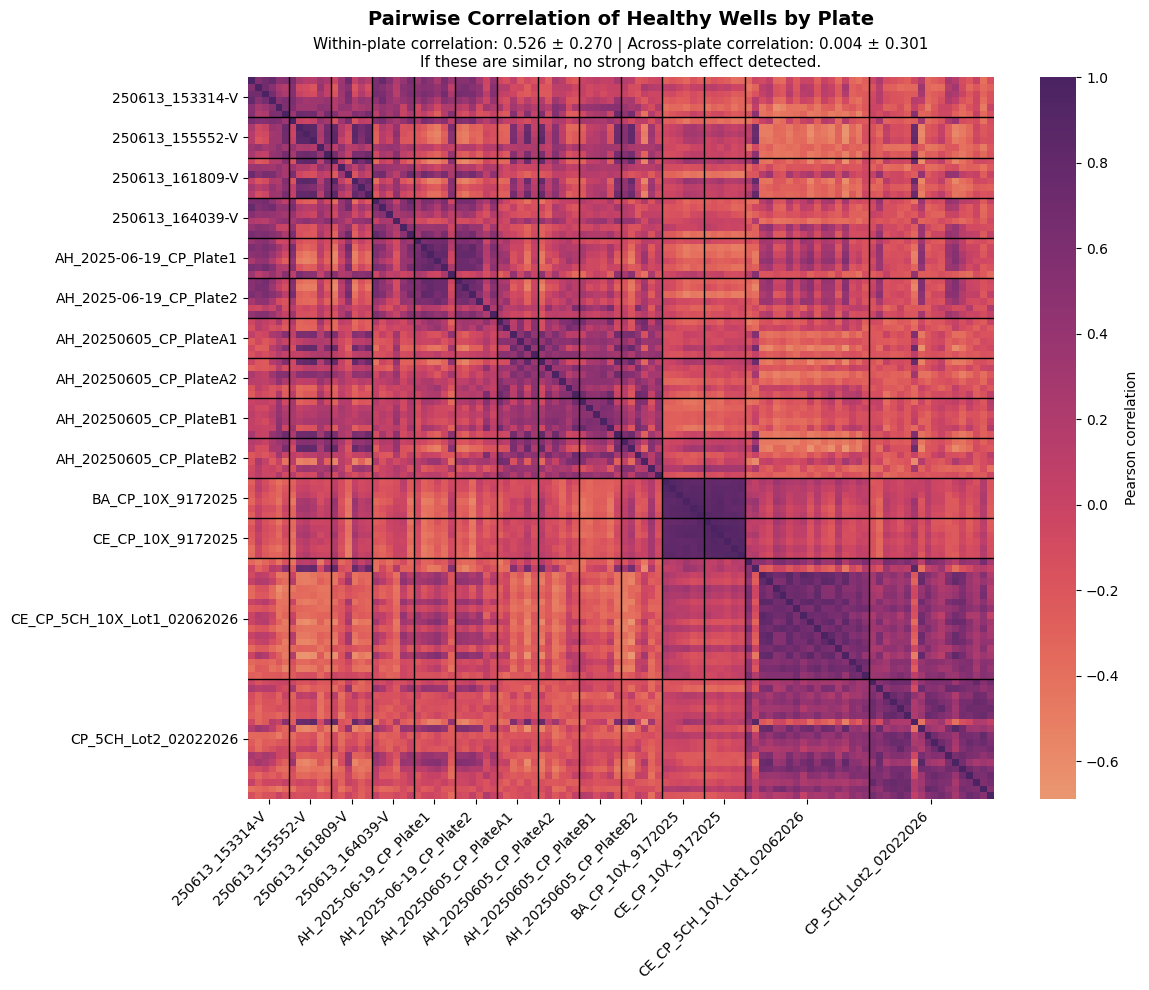

Within-plate correlation: 0.526 ± 0.270
Across-plate correlation: 0.004 ± 0.301

Within-plate and across-plate correlations may be unstable for healthy wells because normalization makes them around 0.


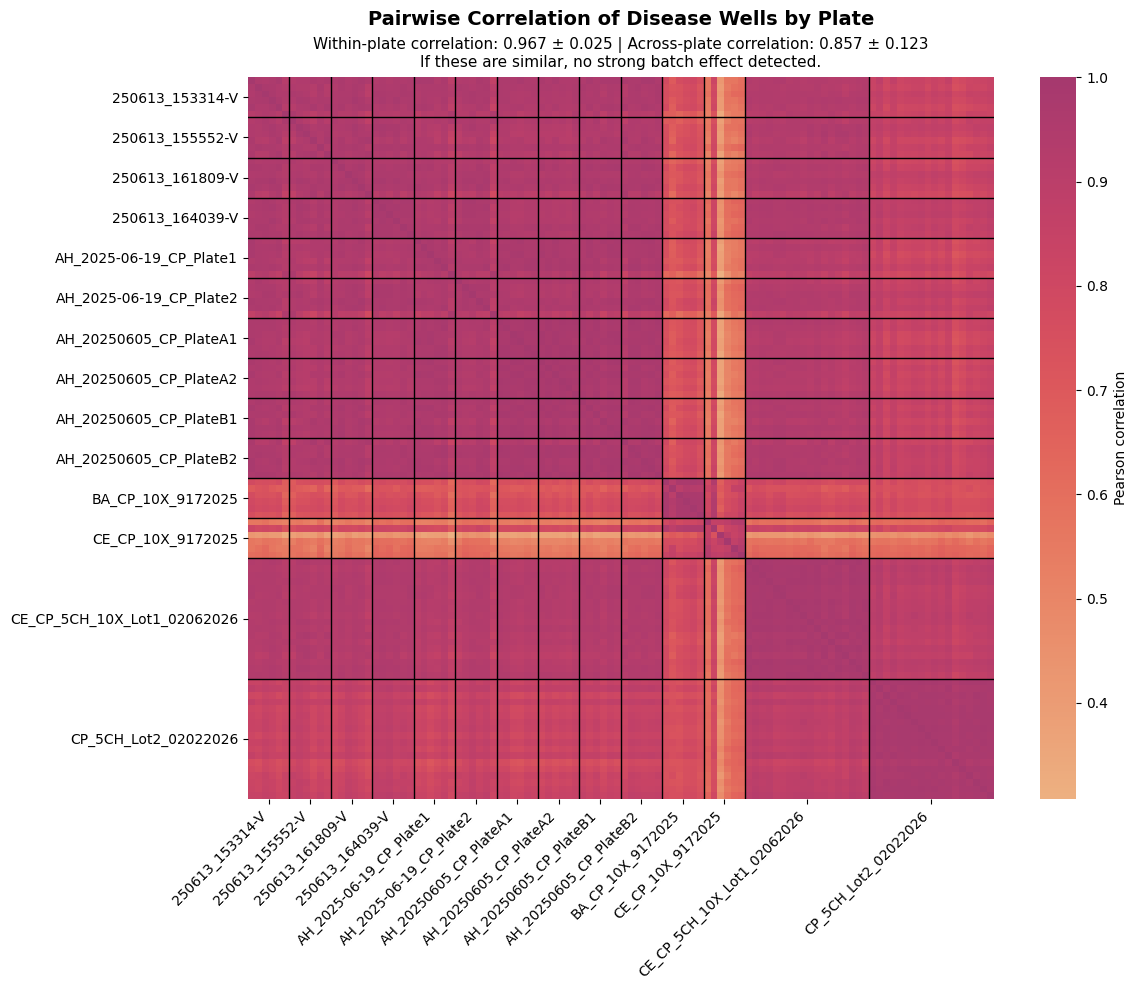

Within-plate correlation: 0.967 ± 0.025
Across-plate correlation: 0.857 ± 0.123


In [1113]:
print("="*60)
print("5. EXAMINE BATCH EFFECTS AFTER NORMALIZATION")
print("="*60)
print()

detect_batch_effects(df_transformed, feature_cols, reference='healthy', similarity='cosine')
print("\nWithin-plate and across-plate correlations may be unstable for healthy wells because normalization makes them around 0.")
detect_batch_effects(df_transformed, feature_cols, reference='disease', similarity='cosine')